## Presentation / Journal Style Plotting for Adaptive Sampling Results

### Preset definition

In [27]:
import seaborn as sns 
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 

class FigPreset:
    def __init__(self, figsize, dpi, context, font_scale,
                 linewidth, markersize, labelsize, ticksize, titlesize, 
                 legendsize):
        self.figsize = figsize
        self.dpi = dpi
        self.context = context
        self.font_scale = font_scale
        self.linewidth = linewidth
        self.markersize = markersize
        self.labelsize = labelsize
        self.ticksize = ticksize
        self.titlesize = titlesize
        self.legendsize=legendsize

    def apply(self):
        sns.set_context(self.context, font_scale=self.font_scale)
        sns.set_style("ticks")
        return self

# Define presets
FULL_FIG = FigPreset((6, 4.5), 300, "paper", 1.2, 2.5, 8, 20, 14, 20, 16)
HALF_FIG = FigPreset((4, 3), 300, "paper", 1.1, 2.0, 6, 14, 12, 18, 12)
SQUARE_FIG = FigPreset((3, 3), 300, "paper", 1.0, 1.8, 5, 12, 10, 16, 12)
DOUBLE_FIG = FigPreset((12, 4.5), 300, "paper", 1.2, 2.5, 8, 20, 14, 20, 16)


### Learning Curves

In [46]:
import json 
import os 

def generate_learning_curves(data_sources, labels, qoi='rmse', title=None, norm_factor=1, y_axis="Normalized RMSE", legend=True, linestyle=None, 
yscale="linear", start_idx=None, labelx = None, labelys = None, label_direct=False): 
    data = []
    if linestyle is None: 
        linestyle = ['-'] * len(data_sources)
    for source in data_sources: 
        with open(os.path.join(source, "performance_data.json"), 'r') as f: 
            new_data = json.load(f)
        data.append(new_data)
    
    #qoi_data = [[eval(step)[qoi] / norm_factor for step in src] for src in data]
    #qoi_samples = [[eval(step)["n_samples"] for step in src] for src in data]

    qoi_data = [np.array(src[qoi]) / norm_factor for src in data]
    print ([data[-1] for data in qoi_data])
    qoi_samples = [src["n_samples"] for src in data]

    preset = HALF_FIG.apply() 
    fig, ax = plt.subplots(figsize = preset.figsize, dpi = preset.dpi)
    for i, label in enumerate(labels): 
        if start_idx is not None:
            if yscale == "linear": 
                ax.plot(qoi_samples[i][start_idx[i]:], qoi_data[i][start_idx[i]:], label=label, c="C" + str(i), linestyle=linestyle[i])
            else: 
                ax.semilogy(qoi_samples[i][start_idx[i]:], qoi_data[i][start_idx[i]:], label=label, c="C" + str(i), linestyle=linestyle[i])
        else: 
            if yscale == "linear": 
                ax.plot(qoi_samples[i], qoi_data[i], label=label, c="C" + str(i), linestyle=linestyle[i])
            else: 
                ax.semilogy(qoi_samples[i], qoi_data[i], label=label, c="C" + str(i), linestyle=linestyle[i])

        if label_direct: 
            ax.annotate(label, (labelx, labelys[i]), c = "C" + str(i), fontsize=preset.legendsize)

    if legend: 
        ax.legend(fontsize=preset.legendsize, loc="center right", bbox_to_anchor=(1,0.4), frameon= False)
            
    if title is not None: 
        ax.set_title(title, fontsize=preset.titlesize, weight="bold")
    ax.set_xlabel("Number of Training Points", fontsize=preset.labelsize)
    ax.set_ylabel(y_axis, fontsize=preset.labelsize)
    ax.tick_params(axis='both', labelsize=preset.ticksize)
    plt.tight_layout()
    plt.show()


In [ ]:
import os 

titles = ["$C_m$", "$C_l$", "$C_d$"]
parent_dirs = ["CM_5D", "CL_5D", "CD_5D"]
norm_factors = [0.0922, 1.1977, 0.0141]
#norm_factors=[1, 1, 1]

for j, parent_dir in enumerate(parent_dirs):
    GRUBS_src = os.path.join(parent_dir, "DE_GRUBS")
    RAND_src = os.path.join(parent_dir, "DE_RAND")
    PREV_src = os.path.join(parent_dir, 'PREV')
    GRUBS_CQR_src = os.path.join(parent_dir, 'CQR_GRUBS')
    US_GP_src  = os.path.join(parent_dir, 'US_GP')

    generate_learning_curves([GRUBS_src, GRUBS_CQR_src, RAND_src, US_GP_src, PREV_src], 
                             ["GRUBS_DE", "GRUBS_CQR", "Random", "US_GP", "Previous Adaptive"], 
                             qoi='rmse', title=titles[j], norm_factor=norm_factors[j], legend=(j==0), 
                             linestyle=['-', '-', ':', ':', ':'])

[np.float64(0.05512231623934169), np.float64(0.04293985560487008), np.float64(0.031580686080846465)]


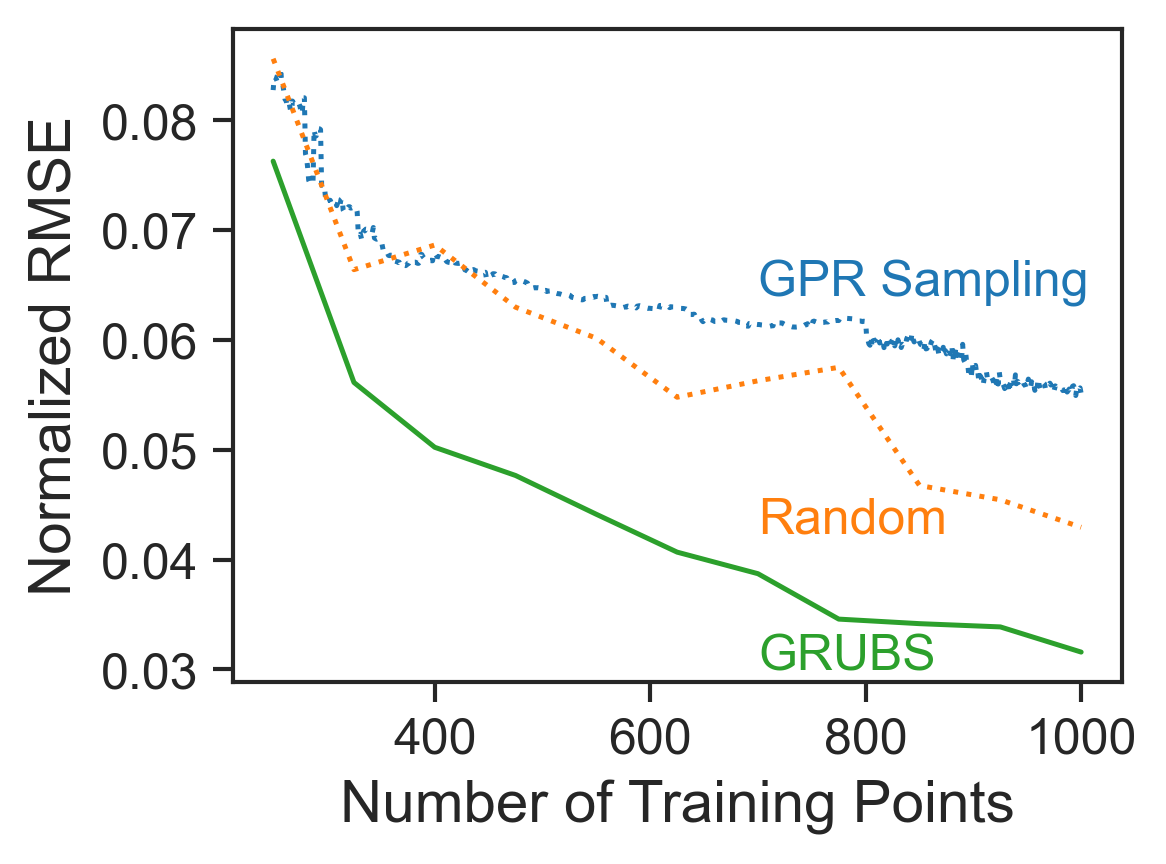

[np.float64(0.04649478438157403), np.float64(0.04670953411234358), np.float64(0.0168621303490268)]


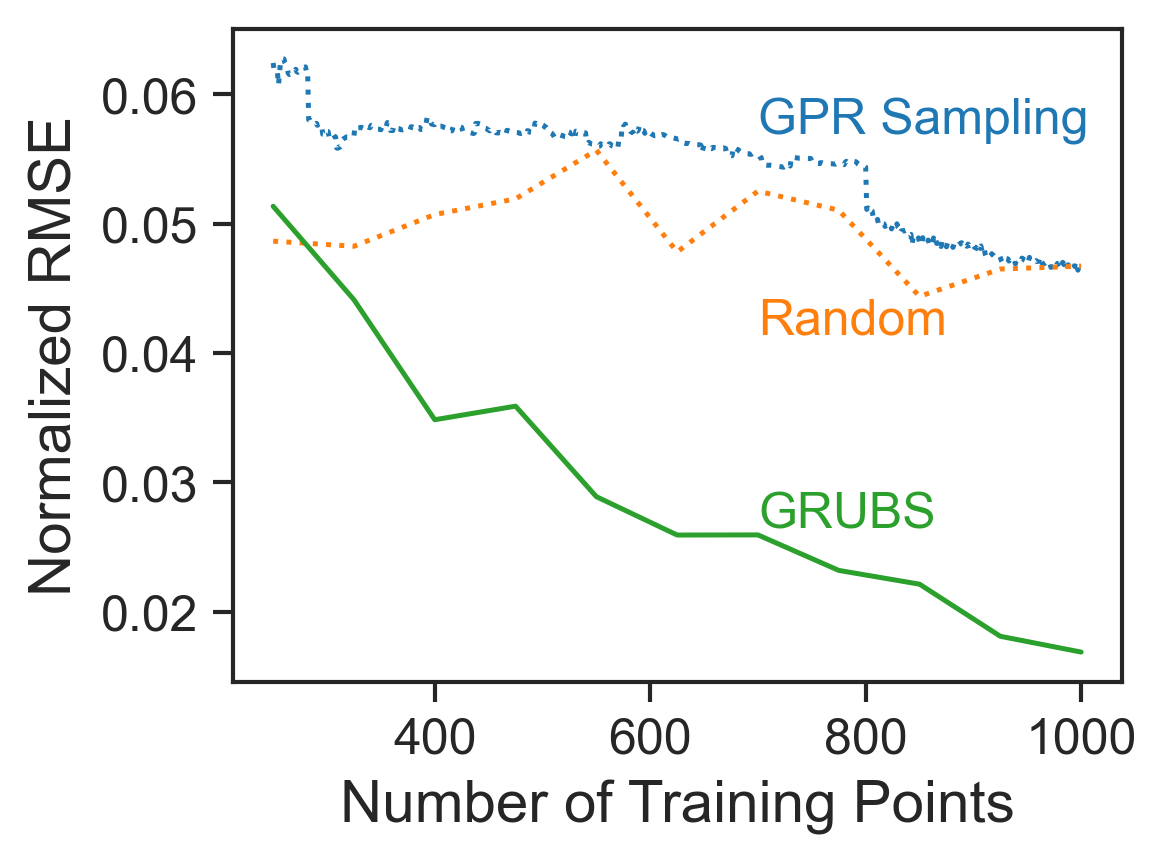

[np.float64(0.9309776822491054), np.float64(0.9215359008762537), np.float64(0.22303250156112062)]


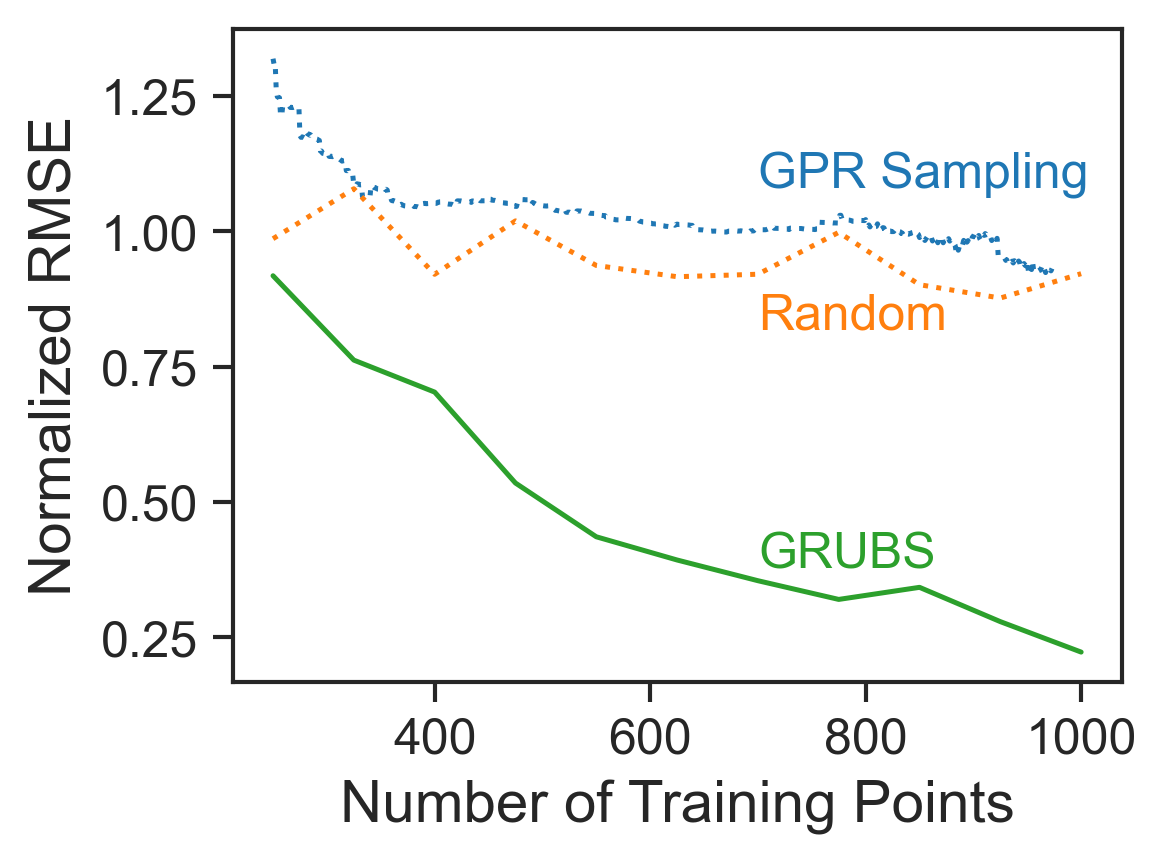

In [90]:
label_locs = [[0.064, 0.0425, 0.03], [0.057, 0.0415, 0.0265], [1.08, 0.82, 0.38]]
for j, parent_dir in enumerate(parent_dirs):
    GRUBS_src = os.path.join(parent_dir, "DE_GRUBS")
    RAND_src = os.path.join(parent_dir, "DE_RAND")
    PREV_src = os.path.join(parent_dir, 'PREV')
    GRUBS_CQR_src = os.path.join(parent_dir, 'CQR_GRUBS')
    US_GP_src  = os.path.join(parent_dir, 'US_GP')

    generate_learning_curves([US_GP_src, RAND_src, GRUBS_src], 
                             ["GPR Sampling", "Random", "GRUBS"], 
                             qoi='rmse', norm_factor=norm_factors[j], legend=False, 
                             linestyle=[':', ':', '-'], labelx=700, labelys= label_locs[j], label_direct=True)

In [7]:
import json 
import os 

def generate_learning_curves(data_sources, labels, qoi='rmse', title=None): 
    data = []
    for source in data_sources: 
        with open(os.path.join(source, "performance_data.json"), 'r') as f: 
            new_data = json.load(f)
        data.append(new_data)
    qoi_data = [[eval(step)[qoi] / 0.1 for step in src] for src in data]
    qoi_samples = [[eval(step)["n_samples"] for step in src] for src in data]

    preset = FULL_FIG.apply() 
    fig, ax = plt.subplots(figsize = preset.figsize, dpi = preset.dpi)
    for i, label in enumerate(labels): 
        ax.plot(qoi_samples[i][:-1], qoi_data[i][:-1], label=label, c="C" + str(i))

    ax.legend(fontsize=14, loc="upper right")
    if title is not None: 
        ax.set_title(title, fontsize=preset.titlesize, weight="bold")
    ax.set_xlabel("Number of Training Points", fontsize=preset.labelsize)
    ax.set_ylabel(r"Avg. Interval Width/$\bar{C_m}$", fontsize=preset.labelsize)
    plt.tight_layout()
    plt.show()

In [ ]:
import os 

titles = ["$C_m$", "$C_l$", "$C_d$"]
parent_dirs = ["CM_5D", "CL_5D", "CD_5D"]

qoi_label = 'average_interval_width'

for i, parent_dir in enumerate(parent_dirs):
    GRUBS_src = os.path.join(parent_dir, "GRUBS")
    GRUBS_var_src = os.path.join(parent_dir, "DE_GRUBS")
    RAND_src = os.path.join(parent_dir, "DE_RAND")
    GRUBS_CQR_src = os.path.join(parent_dir, "CQR_GRUBS")
    US_GP_src = os.path.join(parent_dir, "US_GP")

    generate_learning_curves([GRUBS_src, GRUBS_var_src, GRUBS_CQR_src, RAND_src, US_GP_src], 
                             ["GRUBS_DE", "GRUBS_VAR", "GRUBS_CQR", "Random", "US_GP"], 
                             qoi=qoi_label, title=titles[i], y_axis=qoi_label, 
                             linestyle = ['-', '-', '-', ':', ':'])

In [4]:
import pickle
import numpy as np

with open("SHIFTWING_CM/DE_RAND/sampler_arrays.pkl", 'rb') as f: 
    sampler_arrs = pickle.load(f)

print(np.mean(sampler_arrs['y_exact']))

-0.1598206041233909


[np.float64(0.043596283436963305), np.float64(0.02427958288977541), np.float64(0.02597618597670143)]


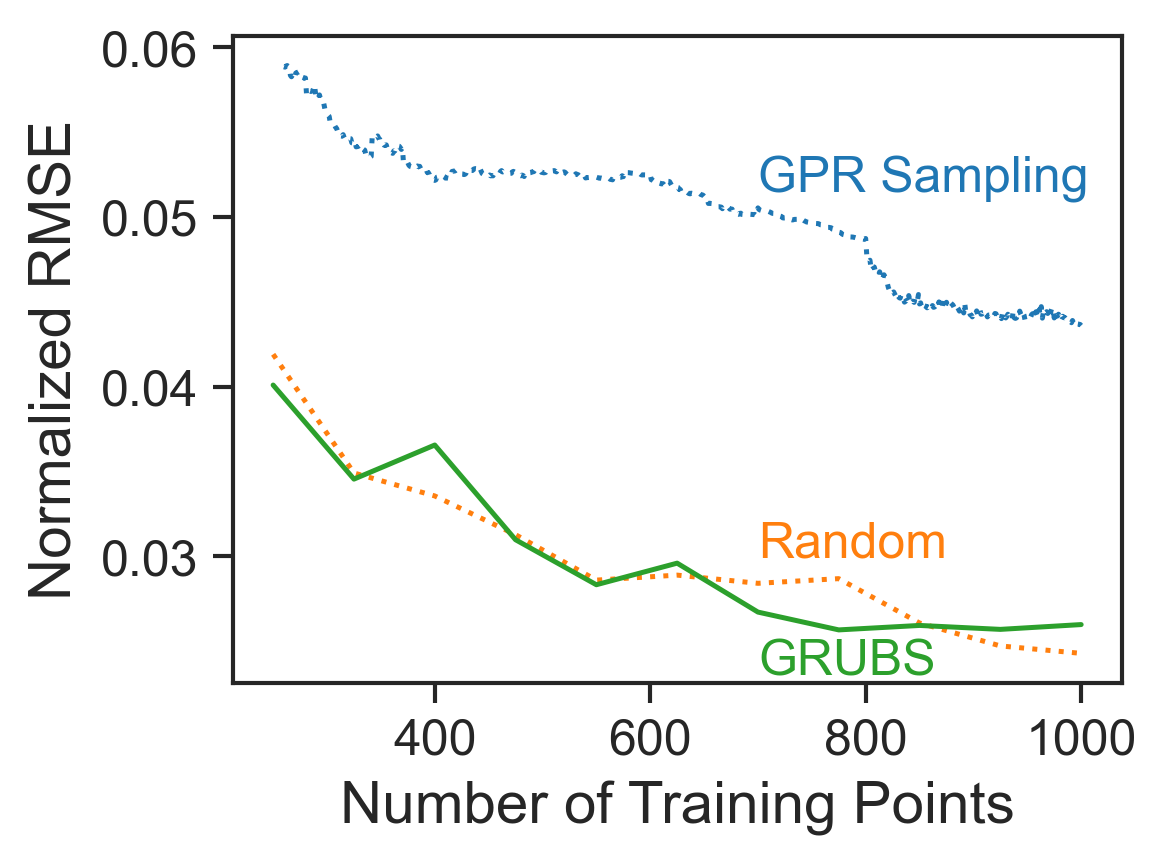

[np.float64(0.04040469637070257), np.float64(0.016517256076681978), np.float64(0.01293948800898955)]


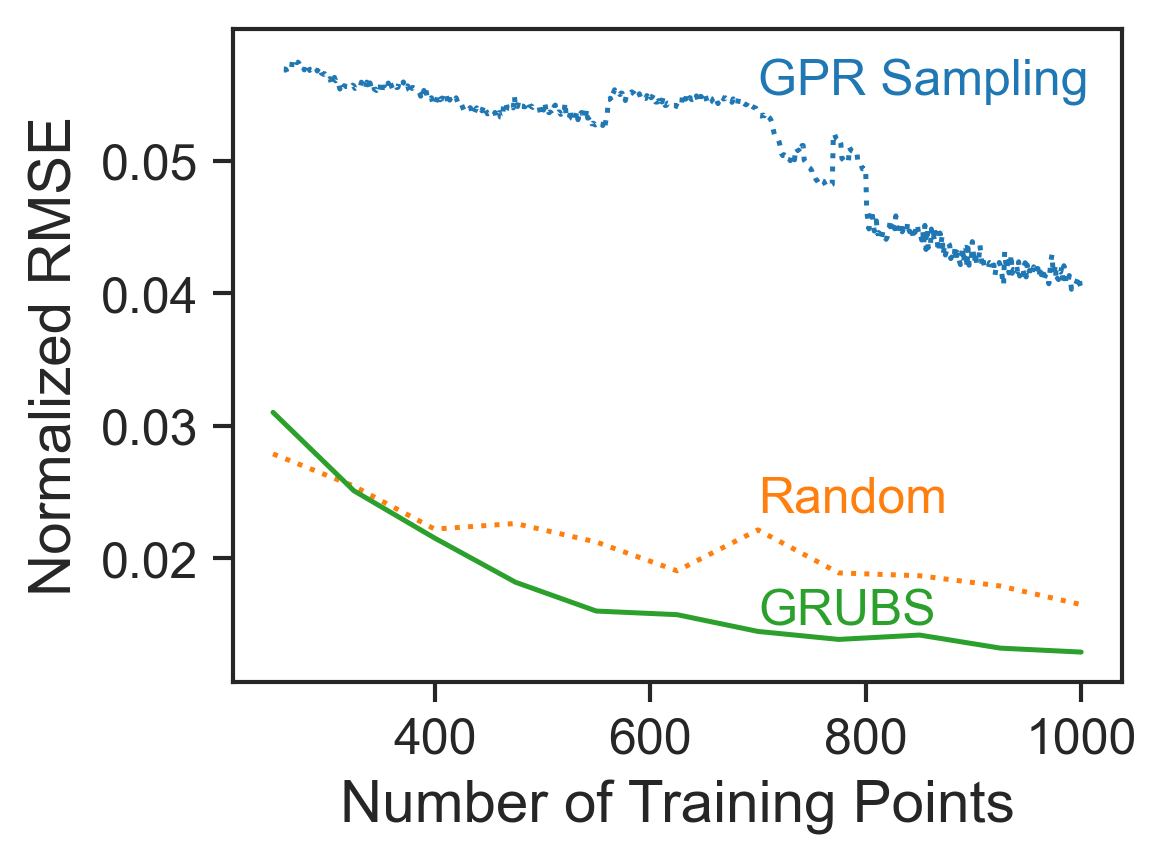

[np.float64(0.05831843655044449), np.float64(0.03151454916632677), np.float64(0.02754235689584153)]


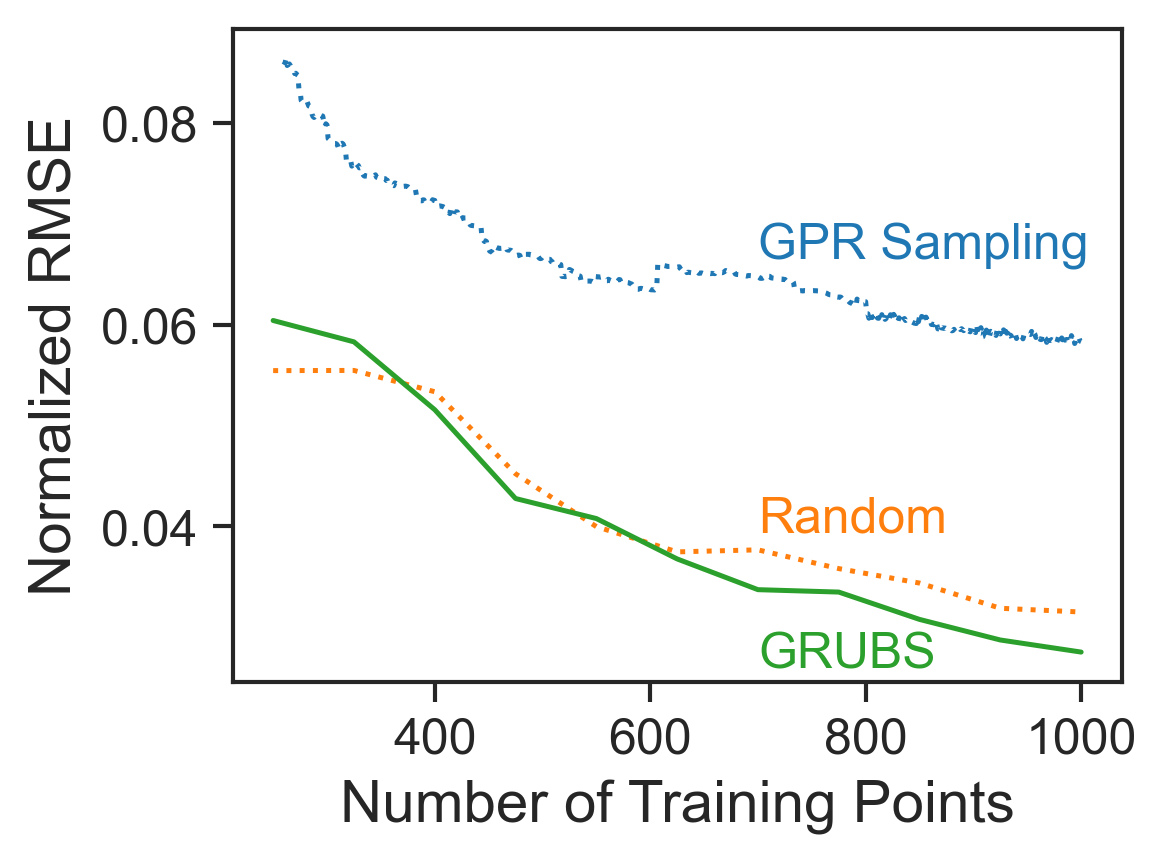

In [98]:
label_locs = [[0.0515, 0.03, 0.023], [0.055, 0.0235, 0.015], [0.0665, 0.0395, 0.026]]
shiftwing_norm_factors = [0.4523, 0.02833, 0.1598]
shiftwing_parent_dirs = ["SHIFTWING_CL", "SHIFTWING_CD", "SHIFTWING_CM"]

for i, parent_dir in enumerate(shiftwing_parent_dirs):
    GRUBS_src = os.path.join(parent_dir, "DE_GRUBS")
    RAND_src = os.path.join(parent_dir, "DE_RAND")
    US_src = os.path.join(parent_dir, "US_GP")

    generate_learning_curves([US_src, RAND_src, GRUBS_src], 
                             ["GPR Sampling", "Random", "GRUBS"], 
                             qoi='rmse', norm_factor=shiftwing_norm_factors[i], legend=False, 
                             linestyle=[':', ':', '-'], yscale="linear", start_idx = [10, 0, 0], label_direct=True, labelx=700, labelys=label_locs[i])

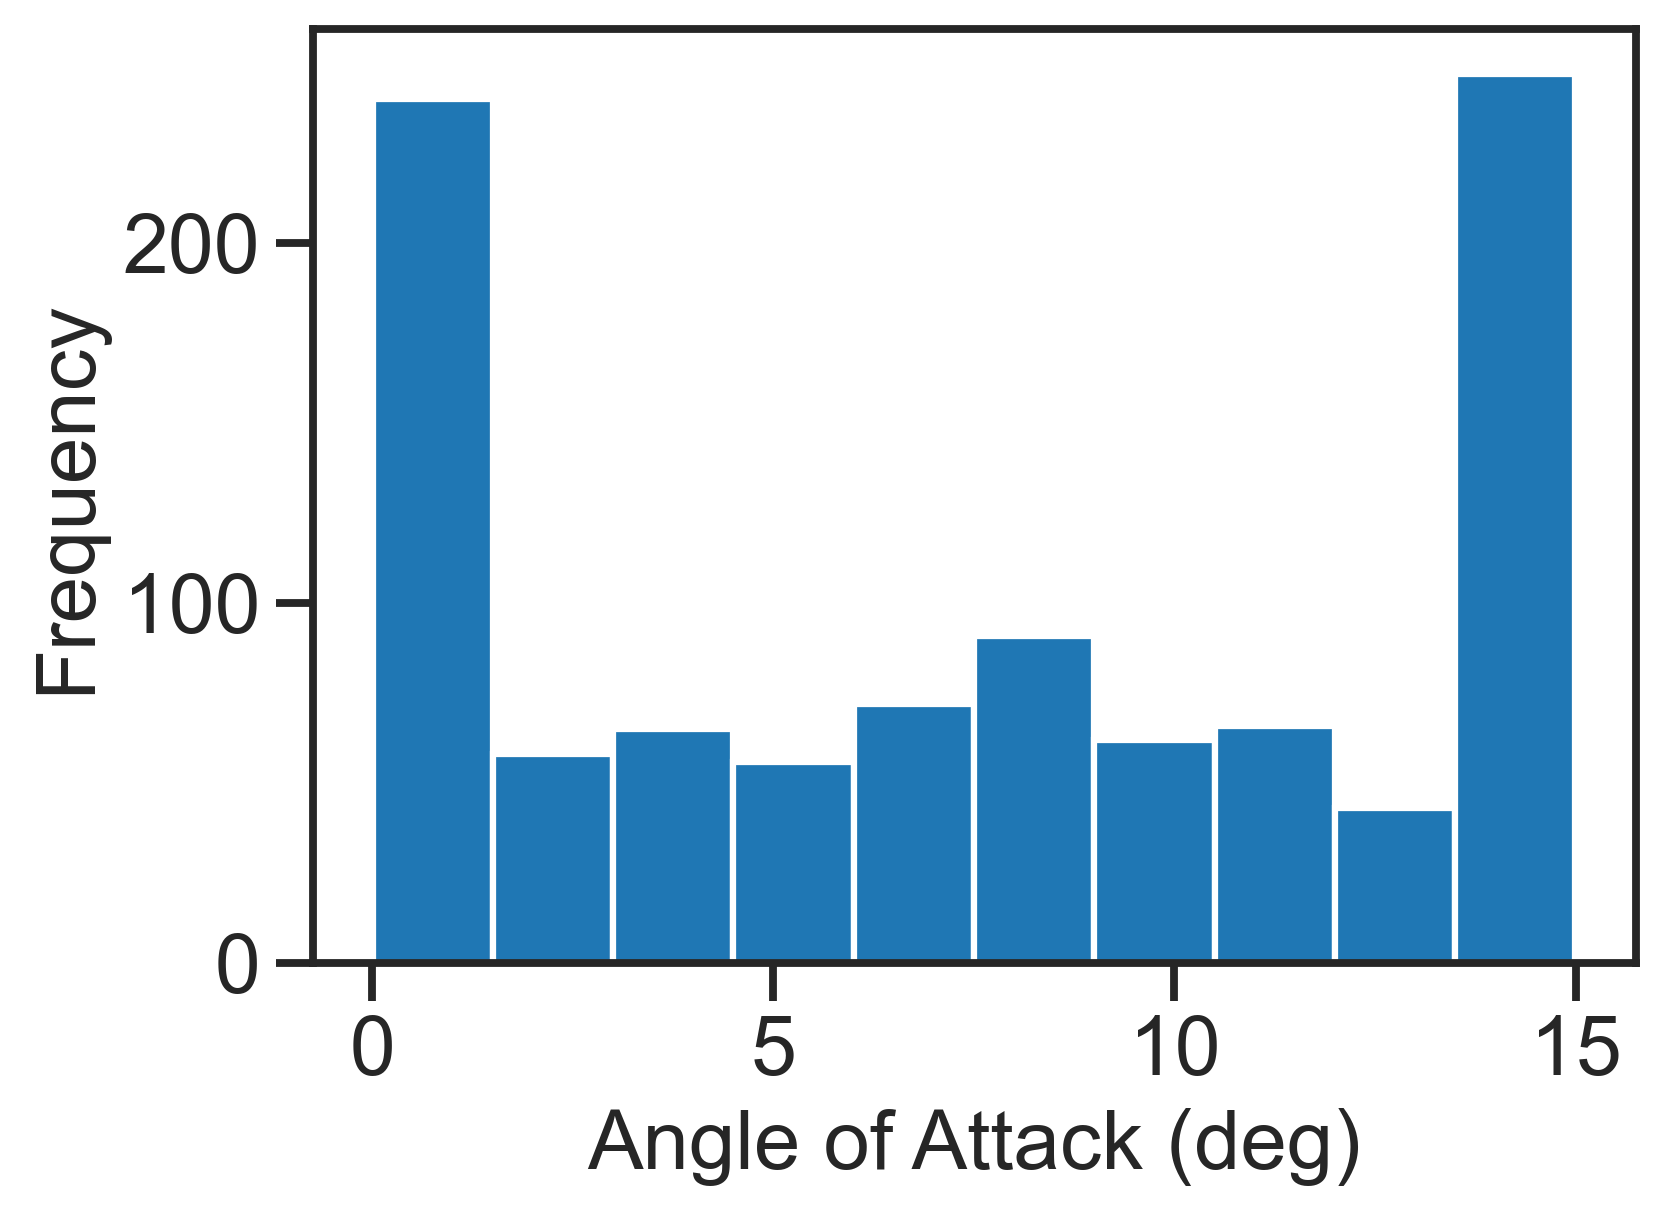

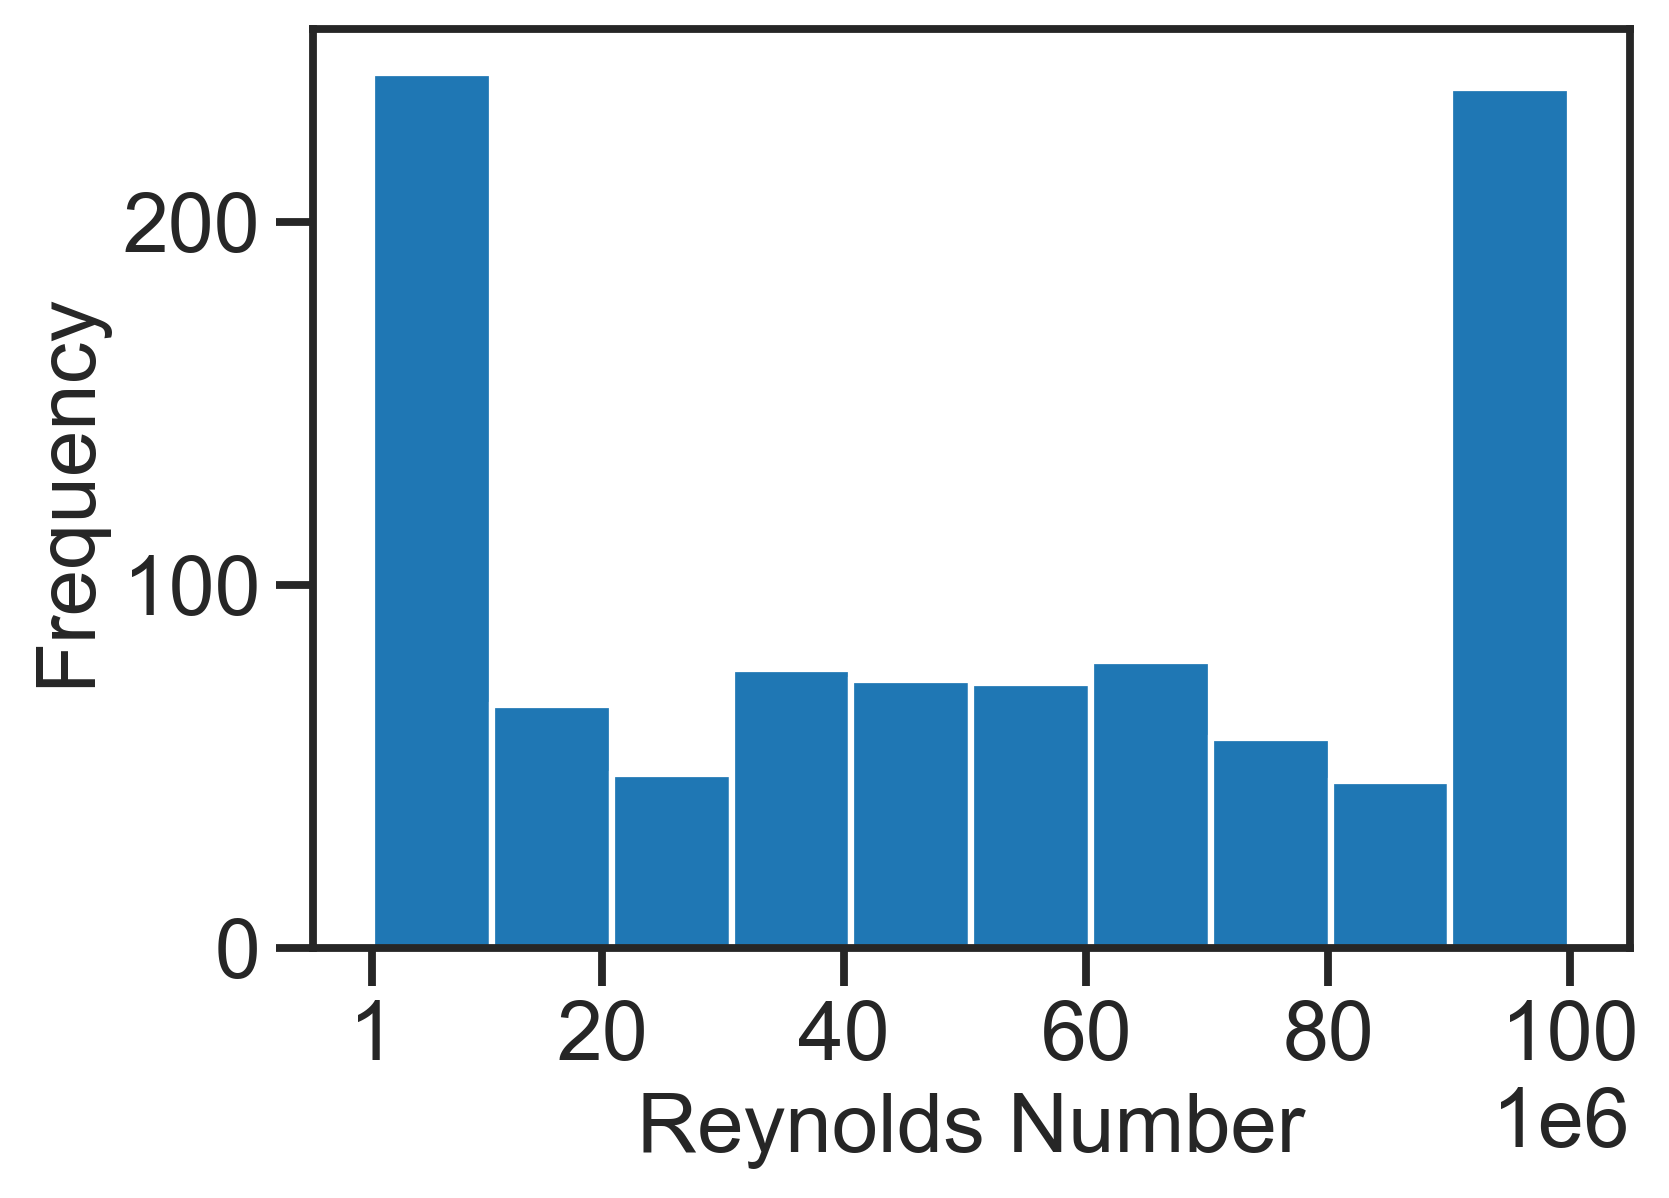

In [43]:
PATH = "CL_5D/US_GP/sampler_arrays.pkl"
import pickle 

with open(PATH, 'rb') as f: 
    arrays = pickle.load(f)

x = arrays['x_exact']

Re = x[:, 3]
alpha = x[:, 4]

preset = FULL_FIG.apply()

fig, ax = plt.subplots(figsize = preset.figsize, dpi = preset.dpi)
ax.set_xlabel("Angle of Attack (deg)", fontsize=preset.labelsize)
ax.set_ylabel("Frequency", fontsize=preset.labelsize)
ax.hist(alpha)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize = preset.figsize, dpi = preset.dpi)
ax.set_xlabel("Reynolds Number", fontsize=preset.labelsize)
ax.set_ylabel("Frequency", fontsize=preset.labelsize)
ax.hist(Re)
ax.ticklabel_format(style='sci',scilimits=(6, 6), axis='x')
ax.set_xticks(np.array([1, 20, 40, 60, 80, 100]) * 10 ** 6)
plt.tight_layout()
plt.show()

